# ENSANUT 2018 EDA
Canonical anthropometry, documented code validation, and weighted descriptive summaries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path('../../data/ensanut_integrated.csv')
RESULTS_DIR = Path('./results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH, low_memory=False)

def num(s):
    return pd.to_numeric(
        s.astype('string').str.replace(',', '.', regex=False).str.strip(),
        errors='coerce'
    )

# Convert only variables that are expected to be numeric.
for c in [
    'EDAD', 'ENT', 'REGION', 'SEXO', 'P8_9',
    'WEIGHT_FINAL', 'HEIGHT_FINAL', 'FACTOR', 'FACTOR_EXPANSION'
]:
    if c in df.columns:
        df[c] = num(df[c])

required = {'EDAD', 'ENT', 'REGION', 'SEXO', 'WEIGHT_FINAL', 'HEIGHT_FINAL'}
missing = required - set(df.columns)
if missing:
    raise KeyError(f'Required ENSANUT variables are missing: {sorted(missing)}')

state_mapping = {
    1:'Aguascalientes', 2:'Baja California', 3:'Baja California Sur',
    4:'Campeche', 5:'Coahuila', 6:'Colima', 7:'Chiapas', 8:'Chihuahua',
    9:'Ciudad de México', 10:'Durango', 11:'Guanajuato', 12:'Guerrero',
    13:'Hidalgo', 14:'Jalisco', 15:'Estado de México', 16:'Michoacán',
    17:'Morelos', 18:'Nayarit', 19:'Nuevo León', 20:'Oaxaca', 21:'Puebla',
    22:'Querétaro', 23:'Quintana Roo', 24:'San Luis Potosí', 25:'Sinaloa',
    26:'Sonora', 27:'Tabasco', 28:'Tamaulipas', 29:'Tlaxcala',
    30:'Veracruz', 31:'Yucatán', 32:'Zacatecas'
}

region_mapping = {1:'Norte', 2:'Centro', 3:'Ciudad de México', 4:'Sur'}

ent_codes = set(df['ENT'].dropna().astype(int).unique())
region_codes = set(df['REGION'].dropna().astype(int).unique())

assert ent_codes.issubset(state_mapping), (
    f'Undocumented ENT code(s) found: {sorted(ent_codes - set(state_mapping))}'
)
assert region_codes.issubset(region_mapping), (
    f'Undocumented REGION code(s) found: {sorted(region_codes - set(region_mapping))}'
)

df['Estado'] = df['ENT'].map(state_mapping)
df['Region_Name'] = df['REGION'].map(region_mapping)

# Analysis population: adults aged 20 years or older.
df = df.loc[df['EDAD'].ge(20)].copy()

# Exclude reported pregnancy among women; retain missing pregnancy status.
if 'P8_9' in df.columns:
    women = df['SEXO'].eq(2)
    pregnancy_missing = df.loc[women, 'P8_9'].isna().mean()
    print(f'Pregnancy missing among women: {pregnancy_missing:.1%}')
    df = df.loc[~(df['SEXO'].eq(2) & df['P8_9'].eq(1))].copy()

# Canonical BMI from final weight and height variables.
df['BMI'] = df['WEIGHT_FINAL'] / (df['HEIGHT_FINAL'] / 100) ** 2
valid_bmi = (
    df['BMI'].between(10, 60)
    & df['HEIGHT_FINAL'].between(100, 250)
    & df['WEIGHT_FINAL'].between(25, 250)
)
df.loc[~valid_bmi, 'BMI'] = np.nan

# Use the documented positive expansion factor when available.
weight_candidates = [c for c in ['FACTOR', 'FACTOR_EXPANSION'] if c in df.columns]
weight = next((c for c in weight_candidates if df[c].gt(0).any()), None)

summary = (
    df.groupby('Region_Name', dropna=False)
      .agg(
          N=('BMI', 'count'),
          BMI_mean=('BMI', 'mean'),
          BMI_sd=('BMI', 'std')
      )
      .round(2)
)

if weight is not None:
    def weighted_mean(group):
        x = group[['BMI', weight]].dropna()
        x = x.loc[x[weight] > 0]
        if x.empty:
            return np.nan
        return np.average(x['BMI'], weights=x[weight])

    weighted = df.groupby('Region_Name', dropna=False).apply(
        weighted_mean,
        include_groups=False
    )
    summary['BMI_weighted_mean'] = weighted.round(2)

print(summary)
print('Weight:', weight if weight is not None else 'none; unweighted only')

summary.to_csv(RESULTS_DIR / 'eda_region_summary.csv')


/tmp/ipykernel_3452000/2332829176.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Estado'] = df['ENT'].map(state_mapping)
/tmp/ipykernel_3452000/2332829176.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Region_Name'] = df['REGION'].map(region_mapping)


Pregnancy missing among women: 50.3%
                     N  BMI_mean  BMI_sd  BMI_weighted_mean
Region_Name                                                
Centro            4512     28.33    5.47              28.24
Ciudad de México   374     29.05    5.33              28.92
Norte             2685      29.1    6.11              29.11
Sur               4532      29.0     5.6              28.89
Weight: FACTOR


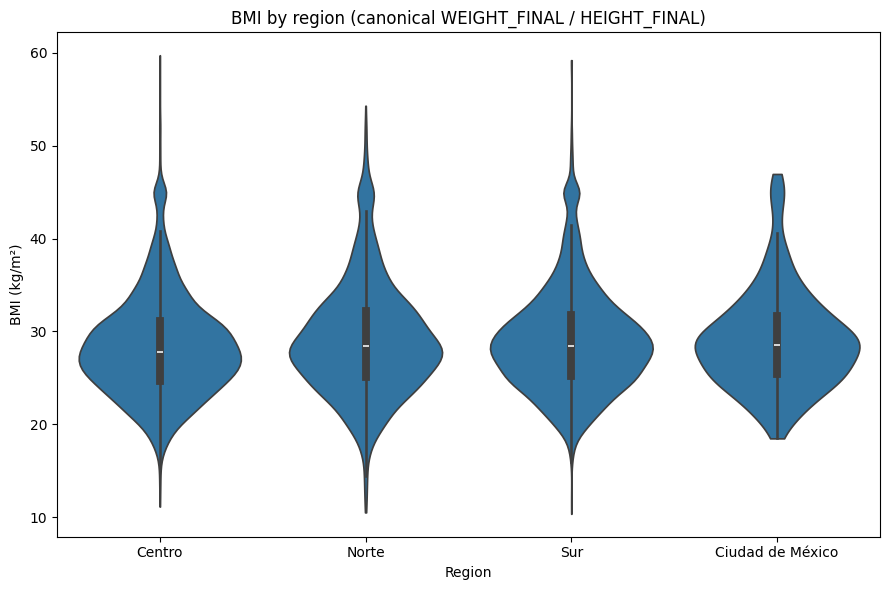

In [2]:
plot_df = df.dropna(subset=['BMI', 'Region_Name']).copy()

if plot_df.empty:
    raise ValueError('No valid observations remain for the BMI plot.')

plt.figure(figsize=(9, 6))
sns.violinplot(data=plot_df, x='Region_Name', y='BMI', cut=0)
plt.title('BMI by region (canonical WEIGHT_FINAL / HEIGHT_FINAL)')
plt.xlabel('Region')
plt.ylabel('BMI (kg/m²)')
plt.tight_layout()
plt.show()


Code catalogs are validated against the ENSANUT 2018 INEGI data dictionary and INSP database-structure documentation. Sample sizes are not used to infer labels.